In [9]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

^C
Note: you may need to restart the kernel to use updated packages.


Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached https://download.pytorch.org/whl/cpu/torch-2.8.0%2Bcpu-cp313-cp313-win_amd64.whl.metadata (29 kB)
  Using cached https://download.pytorch.org/whl/cpu/torchvision-0.23.0%2Bcpu-cp313-cp313-win_amd64.whl.metadata (6.3 kB)
  Using cached https://download.pytorch.org/whl/cpu/torchaudio-2.8.0%2Bcpu-cp313-cp313-win_amd64.whl.metadata (7.4 kB)
  Using cached https://download.pytorch.org/whl/filelock-3.13.1-py3-none-any.whl.metadata (2.8 kB)
  Using cached https://download.pytorch.org/whl/typing_extensions-4.12.2-py3-none-any.whl.metadata (3.0 kB)
  Using cached https://download.pytorch.org/whl/sympy-1.13.3-py3-none-any.whl.metadata (12 kB)
  Using cached https://download.pytorch.org/whl/networkx-3.3-py3-none-any.whl.metadata (5.1 kB)
  Using cached https://download.pytorch.org/whl/Jinja2-3.1.4-py3-none-any.whl.metadata (2.6 kB)
  Using cached https://download.pytorch.org/whl/fsspec-2024.6.1-py3-none-any.whl.metadata (11 kB

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [18]:
%pip install matplotlib librosa

  Using cached matplotlib-3.10.6-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.60.0-cp313-cp313-win_amd64.whl.metadata (113 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl.metadata (6.4 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
  Using cached audioread-3.0.1-py3-none-any.whl.metadata (8.4 kB)
  Using cached numba-0.62.0-cp313-cp313-win_amd64.whl.metadata (2.9 kB)
  Using cached scipy-1.16.2-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached scikit_learn-1.7.2-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached soundfile-0.13.1-py2.py3-none-win_amd64.whl.metadata (16 kB)
  Using cached pooch-1.8.2-py3-none-any.whl.metadata (10 kB)
  Using cached s

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [25]:
%pip install soundfile

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torchaudio
import matplotlib.pyplot as plt
from IPython.display import Audio
import librosa
import os

In [3]:
libri= torchaudio.datasets.LIBRISPEECH('./corpus', url='train-clean-100')

In [4]:
libri[0]

c:\Users\21mar\Downloads\voice_chatbot\fc-asr\.venv\Lib\site-packages\torchaudio\_backend\utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


(tensor([[ 1.3123e-03,  2.5635e-03,  1.5259e-03,  ..., -3.9062e-03,
          -3.0518e-05, -1.9531e-03]]),
 16000,
 'EVERY PROMISE OF THE SOUL HAS INNUMERABLE FULFILMENTS EACH OF ITS JOYS RIPENS INTO A NEW WANT NATURE UNCONTAINABLE FLOWING FORELOOKING',
 1088,
 129236,
 0)

In [5]:
waveform, sample_rate, transcript, _, _, _ = libri[0]

In [6]:
Audio(waveform.numpy(), rate=sample_rate)

In [7]:
libri.get_metadata(0)

('train-clean-100\\1088\\129236\\1088-129236-0000.flac',
 16000,
 'EVERY PROMISE OF THE SOUL HAS INNUMERABLE FULFILMENTS EACH OF ITS JOYS RIPENS INTO A NEW WANT NATURE UNCONTAINABLE FLOWING FORELOOKING',
 1088,
 129236,
 0)

In [8]:
waveform2, sample_rate2= torchaudio.load(os.path.join('./corpus/LibriSpeech/',libri.get_metadata(0)[0]))

In [9]:
waveform == waveform2

tensor([[True, True, True,  ..., True, True, True]])

In [10]:
def plot_waveform(waveform, sample_rate):
    waveform = waveform.numpy()

    num_channels, num_frames = waveform.shape
    time_axis = torch.arange(0, num_frames) / sample_rate

    figure, axes = plt.subplots(num_channels, 1)
    if num_channels == 1:
        axes = [axes]
    for c in range(num_channels):
        axes[c].plot(time_axis, waveform[c], linewidth=1)
        axes[c].grid(True)
        if num_channels > 1:
            axes[c].set_ylabel(f"Channel {c+1}")
    figure.suptitle("waveform")

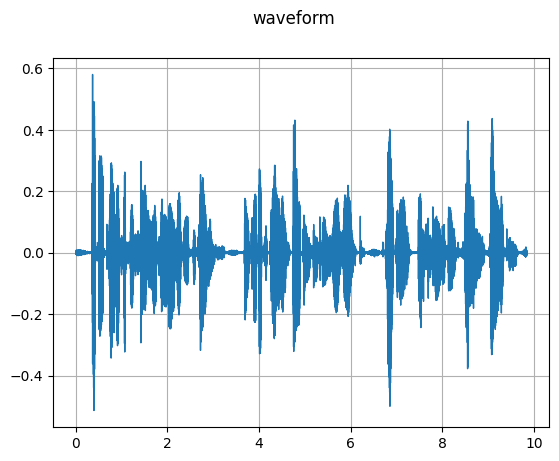

In [11]:
plot_waveform(waveform, sample_rate)

In [12]:
import torchaudio.transforms as T


class MyPipeline(torch.nn.Module):
    def __init__(
        self,
        input_freq=16000,
        resample_freq=16000,
        n_fft=400,
        hop_length=160,
        n_mel=80,
        stretch_factor=0.8,
    ):
        super().__init__()
        self.resample = T.Resample(orig_freq=input_freq, new_freq=resample_freq)

        self.spec = T.Spectrogram(n_fft=n_fft, power=2)
        self.mel_scale = T.MelScale(
            n_mels=n_mel, sample_rate=resample_freq, n_stft=n_fft // 2 + 1)
    def forward(self, waveform: torch.Tensor) -> torch.Tensor:
        # Resample the input
        resampled = self.resample(waveform)

        # Convert to power spectrogram
        spec = self.spec(resampled)

        # Convert to mel-scale
        mel = self.mel_scale(spec)

        return mel

In [13]:
# Instantiate a pipeline
pipeline = MyPipeline()

# Perform the transform
features = pipeline(waveform)


In [14]:
def plot_spectrogram(specgram, title=None, ylabel="freq_bin", ax=None):
    if ax is None:
        _, ax = plt.subplots(1, 1)
    if title is not None:
        ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.imshow(librosa.power_to_db(specgram), origin="lower", aspect="auto", interpolation="nearest")


In [15]:
features

tensor([[[1.6353e-03, 1.0558e-03, 1.4513e-04,  ..., 9.2218e-04,
          6.1820e-04, 1.8013e-03],
         [5.9198e-03, 3.8219e-03, 5.2539e-04,  ..., 3.3384e-03,
          2.2379e-03, 6.5209e-03],
         [2.4333e-04, 2.1260e-03, 2.3439e-04,  ..., 3.0165e-03,
          1.3150e-04, 5.4595e-03],
         ...,
         [3.0635e-05, 1.7152e-05, 1.9642e-05,  ..., 6.5478e-05,
          8.8799e-05, 2.1563e-04],
         [5.9654e-05, 3.1362e-05, 3.4557e-05,  ..., 1.1623e-04,
          1.0066e-04, 1.4353e-04],
         [3.5076e-05, 3.7683e-05, 1.6617e-04,  ..., 5.9691e-05,
          1.0499e-04, 6.1589e-05]]])

In [16]:
features.shape

torch.Size([1, 80, 788])

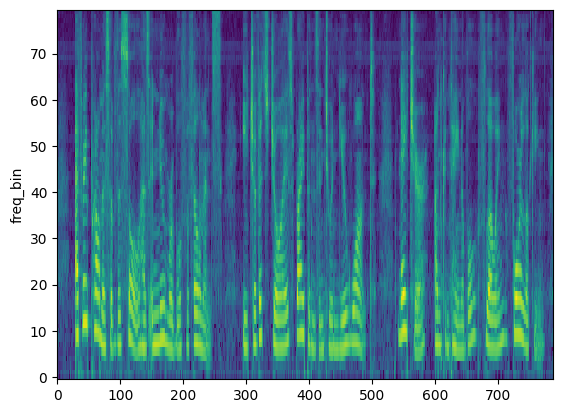

In [17]:
plot_spectrogram(features[0])

In [18]:
class MyPipeline2(torch.nn.Module):
    def __init__(
        self,
        input_freq=16000,
        resample_freq=16000,
        n_fft=400,
        hop_length=160,
        n_mel=80,
        stretch_factor=0.8,
    ):
        super().__init__()
        self.resample = T.Resample(orig_freq=input_freq, new_freq=resample_freq)

        self.spec = T.Spectrogram(n_fft=n_fft, power=2)
        self.spec_aug = torch.nn.Sequential(
            T.TimeStretch(stretch_factor, fixed_rate=True),
            T.FrequencyMasking(freq_mask_param=80),
            T.TimeMasking(time_mask_param=80),
        )
        self.mel_scale = T.MelScale(
            n_mels=n_mel, sample_rate=resample_freq, n_stft=n_fft // 2 + 1)
    def forward(self, waveform: torch.Tensor) -> torch.Tensor:
        # Resample the input
        resampled = self.resample(waveform)

        # Convert to power spectrogram
        spec = self.spec(resampled)
        
        # Apply SpecAugment
        spec = self.spec_aug(spec)

        # Convert to mel-scale
        mel = self.mel_scale(spec)

        return mel

In [19]:
# Instantiate a pipeline
pipeline2 = MyPipeline2()

# Perform the transform
features2 = pipeline2(waveform)

c:\Users\21mar\Downloads\voice_chatbot\fc-asr\.venv\Lib\site-packages\torch\nn\modules\container.py:244: UserWarning: The input to TimeStretch must be complex type. Providing non-complex tensor produces invalid results.
  input = module(input)


In [20]:
features2.shape

torch.Size([1, 80, 788])

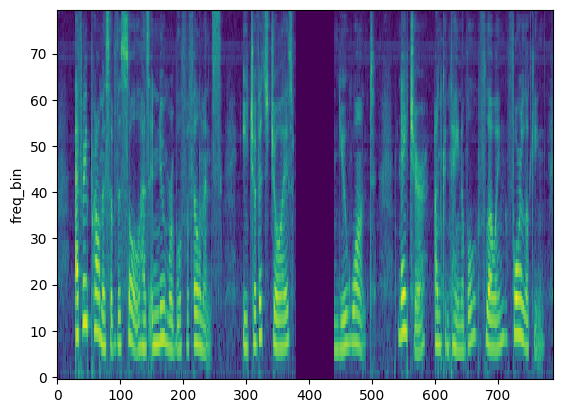

In [21]:
plot_spectrogram(features2[0])